# Problème 1 (1h30)

Dans ce problème, on étudie la situation suivante. On dispose dans une zone donnée de deux cents capteurs ponctuels fixes. Ces capteurs échantillonnent parfaitement un champ scalaire 2D stationnaire qu'on va chercher à reconstruire. Mais il y a un obstacle : sur les deux cents capteurs disponibles, cent sont mal positionnés. Précisément, on connaît parfaitement la position des cents premiers capteurs à disposition (dans l'ordre des identifiants), mais la positions des cents suivants est inconnue (on sait seulement qu'ils n'occupent pas les "bords" du champ 2D).

La figure qui est générée trois cellules plus bas résume la situation (Onglet visualisation). On y voit une figure en noir et blanc simulaire aux champs 2D à reconstruire, des capteurs bien positionnés (croix bleues), ainsi que des capteurs mal positionnés (points rouges).

Le but du problème est de parvenir à trouver la position de tous les capteurs tout en reconstruisant le champ (pour rester raisonnable, nous nous conterons d'essayer de déterminer ces positions à une distance de cinq pixels maximum, sur les 64x64 que comporteront les images de travail). Il faut bien comprendre que les champs échantillonnées (clef "discs_gt" dans le batch) ne devront pas être utilisés autrement que pour mesurer des scores. Néanmoins, on supposera qu'il existe une base d'exemples de champs 2D de la même nature que ceux qu'on cherche à échantillonner (clef "discs_gan").



Dans la première partie, nous mettons en oeuvre une première méthode, relativement simple.
Dans la seconde partie, il s'agira d'implémenter un GAN en vue d'exploiter les champs 2D supplémentaires.
Dans la troisième partie, vous êtes invité à combiner les deux et à comparer.

# Imports et fonctions utiles



In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import IterableDataset
import numpy as np
import math
from random import randint
import matplotlib.pyplot as plt
from torch.nn.utils import spectral_norm
#############################################################
#pour la génération des images    ###########################
#############################################################

def simu_rec(image, L,l,  fields=0):
    channels,size,size2=image.size()
    rec= torch.zeros(channels,size,size2)
    #out = 0*(image.clone())
    vertical=np.random.binomial(1,0.5)==1
    if vertical:
        width=l
        height=L
    else:
        width=L
        height=l

    top=randint(0, size-height)
    left=randint(0, size-width)
    rec[fields,top:top+height,left:left+width]=  np.random.uniform(0,0.4)   #0.1
    image=image + rec
    return image

def simu_noisy_rec(image, L,l,  fields=0):
    channels,size,size2=image.size()
    rec= torch.zeros(channels,size,size2)
    #out = 0*(image.clone())
    vertical=np.random.binomial(1,0.5)==1
    if vertical:
        width=l
        height=L
    else:
        width=L
        height=l

    top=randint(0, size-height)
    left=randint(0, size-width)
    rec[fields,top:top+height,left:left+width]= np.random.uniform(0,0.4)  #0.1
    noise=torch.randn(channels,size,size2)
    noise=noise*(noise>0).float()
    rec=noise*rec
    image=image + rec
    return image

def simu_disc(image, f, radius=15, fields=0 ):  #radial decrease function  #or 12
    channels,size,size2=image.size()
    center=np.array([randint(-radius, size+radius) , randint(-radius, size+radius) ])
    npdisc= f( ((np.arange(0,64)*np.ones([size,size])) - center[0])**2 + (np.transpose(np.arange(0,64)*np.ones([size,size]))-center[1])**2  , radius)
    npdisc=np.random.uniform(0.6,1.) * npdisc  #variation on intensity
    image[fields,:,:] = image[fields,:,:] + torch.from_numpy(npdisc).float()   #matrice des distances < rayon
    return image

def simu_disc_with_cond(image, f, radius=15, fields=0, f2 = lambda a,x  : ((np.sin(3.1 * a/x**2)))*(a < x**2) ):  #radial decrease function  #or 12
    channels,size,size2=image.size()
    center=np.array([randint(radius-5, size-radius+2) , randint(radius-2, size-radius+5) ])
    npdisc= f( ((np.arange(0,64)*np.ones([size,size])) - center[0])**2 + (np.transpose(np.arange(0,64)*np.ones([size,size]))-center[1])**2  , radius)
    npdisc=np.random.uniform(0.6,1.) * npdisc  #variation on intensity
    image[0,:,:] = image[0,:,:] + torch.from_numpy(npdisc).float()   #matrice des distances < rayon
    if (radius >= 10) and (radius <= 14):
        npdon = f2( ((np.arange(0,64)*np.ones([size,size])) - center[0])**2 + (np.transpose(np.arange(0,64)*np.ones([size,size]))-center[1])**2  , radius)
        image[1,:,:] = image[1,:,:] + torch.from_numpy(npdon).float()**2
    return image


def simu_square(image, f, diag=15, fields=0 ):  #radial decrease function  #or 12
    channels,size,size2 = image.size()
    center=np.array([randint(diag, size-diag) , randint(diag, size-diag) ])

    npsquare = f(  np.abs(np.arange(0,64)*np.ones([size,size]) - center[0]) + \
                   np.abs(np.transpose(np.arange(0,64)*np.ones([size,size]))-center[1]), diag)
#    npsquare = np.abs(np.arange(0,64)*np.ones([size,size]) - center[0])
    npsquare = np.random.uniform(0.6,1.) * npsquare  #variation on intensity
    image[fields,:,:] = image[fields,:,:] + torch.from_numpy(npsquare).float()   #matrice des distances < rayon
    return image


def plot_pairs(image, f = lambda x : x**2):
    horizontal = (torch.randint(0,2,(1,)) > 0.5).item()
#    print(horizontal)
    dist = torch.randint(1,32, (1,)).item()
    if horizontal :
        ordo = torch.randint(0, 64, (1,)).item()
        absi = torch.randint(0, 64 - dist, (1,)).item()
        image[1, ordo, absi:(absi + dist + 1)] \
            += 0.1 + torch.mean(f(image[0, ordo, absi:(absi + dist + 1)]))
    else :
        ordo = torch.randint(0, 64 - dist, (1,)).item()
        absi = torch.randint(0, 64, (1,)).item()
        image[1, ordo:ordo+dist+1, absi] \
            += 0.1 + torch.mean(f(image[0, ordo:ordo+dist+1, absi]))
    return image


def generate_noise(image, lambda_rec=0.001 ,lambda_noisy_rec = 0.001, lambda_disc = 0.001, lambda_square = 0., pola=[0,0.5,0.1]):
    for k in range(np.random.poisson(lambda_disc*64*64)):
        r = randint(5,32)
        image=simu_disc(image, lambda a,x  : (0.39 - 0.36*a/x**2)*(a < x**2) ,radius = r)  #0.47 pour avoir 40 dB
    for k in range(np.random.poisson(lambda_square*64*64)):
        r = randint(5,10)
        image=simu_square(image, lambda a,x  : (0.5 - 0.45*a/x)*(a < x) , diag = r)  #0.47 pour avoir 40 dB
#        print(r)

    for i in range(np.random.poisson(lambda_rec*64*64)):
        L=randint(20,50)
        l=randint(2,10)
        image= simu_rec(image,L,l)
    for j in range(np.random.poisson(lambda_noisy_rec*64*64)):
        L=randint(10,30)
        l=randint(10,30)
        image= simu_noisy_rec(image,L,l)
        # 0.3*np.exp(-0.1 * a/x)*(a < x**2)  #image=simu_disque(image, lambda a,x  : 1.0*(a < x**2)  )
    if pola[0]==1:      #add a pseudo pola field
        image_pola = generate_pola(image,pola)
        image=torch.cat([image,image_pola],dim=0)
    return image


def generate_noise_with_cond(image, lambda_rec=0.001 ,lambda_noisy_rec = 0.001, lambda_disc = 0.001, lambda_square = 0., pola=[0,0.5,0.1]):
    for k in range(np.random.poisson(lambda_disc*64*64)):
        r = randint(6,18)
        image=simu_disc_with_cond(image, lambda a,x  : (0.39 - 0.36*a/x**2)*(a < x**2) ,radius = r)  #0.47 pour avoir 40 dB
    for k in range(np.random.poisson(lambda_square*64*64)):
        r = randint(5,10)
        image=simu_square(image, lambda a,x  : (0.5 - 0.45*a/x)*(a < x) , diag = r)  #0.47 pour avoir 40 dB
#        print(r)

    for i in range(np.random.poisson(lambda_rec*64*64)):
        L=randint(20,50)
        l=randint(2,10)
        image= simu_rec(image,L,l)
    for j in range(np.random.poisson(lambda_noisy_rec*64*64)):
        L=randint(10,30)
        l=randint(10,30)
        image= simu_noisy_rec(image,L,l)
        # 0.3*np.exp(-0.1 * a/x)*(a < x**2)  #image=simu_disque(image, lambda a,x  : 1.0*(a < x**2)  )
    return image


def generate_noise_and_pairs(image, lambda_pairs = 0.01, lambda_rec=0.001 ,lambda_noisy_rec = 0.001, lambda_disc = 0.001, lambda_square = 0., pola=[0,0.5,0.1]):
    for k in range(np.random.poisson(lambda_disc*64*64)):
        r = randint(5,10)
        image=simu_disc(image, lambda a,x  : (0.39 - 0.36*a/x**2)*(a < x**2) ,radius = r)  #0.47 pour avoir 40 dB
    for k in range(np.random.poisson(lambda_square*64*64)):
        r = randint(5,10)
        image=simu_square(image, lambda a,x  : (0.5 - 0.45*a/x)*(a < x) , diag = r)  #0.47 pour avoir 40 dB
#        print(r)

    for i in range(np.random.poisson(lambda_rec*64*64)):
        L=randint(20,50)
        l=randint(2,10)
        image= simu_rec(image,L,l)
    for j in range(np.random.poisson(lambda_noisy_rec*64*64)):
        L=randint(10,30)
        l=randint(10,30)
        image = simu_noisy_rec(image,L,l)
        # 0.3*np.exp(-0.1 * a/x)*(a < x**2)  #image=simu_disque(image, lambda a,x  : 1.0*(a < x**2)  )
    # on ajoute le deuxième canal où les échanges entre signaux seront
    # représentés

    image2 = torch.zeros([1,64, 64])
    image = torch.cat([image,image2], dim = 0 )

    for j in range(np.random.poisson(lambda_pairs*64*64)):

        image = plot_pairs(image)

    return image


def make_image(rec, noisy_rec ,disc,square=0., pola=[0]):
    image=torch.zeros([1,64, 64])
    image = generate_noise(image, lambda_rec=rec, lambda_noisy_rec = noisy_rec,lambda_disc = disc, lambda_square = square, pola= pola)
    return image

def make_image_with_cond(rec, noisy_rec ,disc,square=0., pola=[0]):
    image = torch.zeros([2, 64, 64])
    image = generate_noise_with_cond(image, lambda_rec=rec, lambda_noisy_rec = noisy_rec,lambda_disc = disc, lambda_square = square, pola= pola)
    return image

def make_batch(batch_size, rec, noisy_rec ,disc, square=0., pola=[0] ):
    out = make_image(rec, noisy_rec ,disc , square, pola ).unsqueeze(0)
    for i in range(batch_size-1):
        new=make_image(rec, noisy_rec ,disc, square, pola).unsqueeze(0)
        out=torch.cat((out,new), dim=0)
    return out

def make_batch_with_cond(batch_size, rec, noisy_rec ,disc, square=0.):
    out = make_image_with_cond(rec, noisy_rec ,disc , square).unsqueeze(0)
    for i in range(batch_size-1):
        new=make_image_with_cond(rec, noisy_rec ,disc, square).unsqueeze(0)
        out=torch.cat((out,new), dim=0)
    return out

def make_image_with_pairs(rec, freq_integrated_signals, noisy_rec ,disc,square=0., pola=[0]):
    image=torch.zeros([1,64, 64])
    image = generate_noise_and_pairs(image, lambda_pairs = freq_integrated_signals, lambda_rec=rec, lambda_noisy_rec = noisy_rec,lambda_disc = disc, lambda_square = square, pola= pola)
    return image

def make_batch_with_pairs(batch_size, freq_integrated_signals, rec, noisy_rec, disc, square=0., pola=[0] ):
    out=make_image_with_pairs(rec, freq_integrated_signals, noisy_rec ,disc , square, pola ).unsqueeze(0)
    for i in range(batch_size - 1):
        new=make_image_with_pairs(rec, freq_integrated_signals, noisy_rec, disc, square, pola).unsqueeze(0)
        out=torch.cat((out,new), dim = 0)
    return out

def gen(n):  #exercice 1 partie 1
  target = make_batch(n, rec = 0., noisy_rec= 0., disc = 0.002)
  noise =  make_batch(n, rec = 0.0003, noisy_rec= 0.0003, disc = 0.)
  return  target + noise, target     #bruit additif trivial

def gen_noise2noise(n):
  target = make_batch(n, rec = 0., noisy_rec= 0., disc = 0.002)
  noise1 =  make_batch(n, rec = 0.0005, noisy_rec= 0.0005, disc = 0.)
  noise2 =  make_batch(n, rec = 0.0005, noisy_rec= 0.0005, disc = 0.)
  return  target + noise1, target + noise2

def gen1_NES(n):
  noisy_image = make_batch(n, rec = 0.0003, noisy_rec= 0.0003, disc = 0.002)
  return  noisy_image

def gen2_NES(n):
  noise1 =  make_batch(n, rec = 0.0003, noisy_rec= 0.0003, disc = 0.)
  return  noise1


def gen_proba(n):
  target1 = make_batch(n, rec = 0., noisy_rec= 0., disc = 0.001)
  m1 = torch.normal(target1**2, 0.2*target1)
  input = target1
  target =   m1
  return  input, target

def gen_ponct(n, p = 0.01):
  input = make_batch(n, rec = 0., noisy_rec= 0., disc = 0.001)
  fulltarget = 2*input**2
  sb = torch.bernoulli(0*fulltarget + p)         # En moyenne,2% des pixels sont couverts par une mesure ponctuelle

  #cible fragmentaire
  target = fulltarget*(sb) + (-1)*(1 - sb)

  return  input, target, fulltarget


def gen_condDCGAN(n, p = 0.01):
  x = make_batch(n, rec = 0., noisy_rec= 0., disc = 0.001, square = 0.)
  fulltarget = x #2*x**2
#  sb = (make_batch(n, rec = 0., noisy_rec= 0., disc = p, square = 0.)> 0.1
  sb = torch.bernoulli(0*fulltarget + p)         # En moyenne,2% des pixels sont couverts par une mesure ponctuelle
  #cond (ex. cible fragmentaire)
  y = fulltarget*sb + (-0.1)*(1 - sb)

  z = torch.randn(*fulltarget.size())
  return  x, y, z


def get_discs(n, lambda_rec = 0.):
  x = make_batch(n, rec = lambda_rec, noisy_rec= 0., disc = 0.002, square = 0.)
  fulltarget = x #2*x**2

  return  x


def _ensure_bchw(x):
    # handle tuple/list outputs from get_discs
    if isinstance(x, (tuple, list)):
        x = x[0]
    if not torch.is_tensor(x):
        raise TypeError(f"get_discs must return a Tensor or (Tensor, ...), got {type(x)}")

    if x.dim() == 3:   # (B,H,W)
        x = x.unsqueeze(1)
    elif x.dim() == 2: # (H,W)
        x = x.unsqueeze(0).unsqueeze(0)
    elif x.dim() != 4:
        raise ValueError(f"Unexpected tensor shape {tuple(x.shape)}")
    return x


def _pix_to_grid(coords_xy: torch.Tensor, H: int, W: int) -> torch.Tensor:
    """
    coords_xy: (...,2) in pixels (x,y)
    returns:   (...,2) in grid_sample coords (x,y) in [-1,1]
    align_corners=True
    """
    x = coords_xy[..., 0]
    y = coords_xy[..., 1]
    xg = 2.0 * x / (W - 1) - 1.0
    yg = 2.0 * y / (H - 1) - 1.0
    return torch.stack([xg, yg], dim=-1)


@torch.no_grad()
def _sample_at_coords_batched(discs_bchw: torch.Tensor, coords_xy: torch.Tensor) -> torch.Tensor:
    """
    discs_bchw: (B,1,H,W)
    coords_xy:  (N,2) pixel coords OR (B,N,2) pixel coords
    returns:    (B,N) sampled values (bilinear interpolation)
    """
    B, _, H, W = discs_bchw.shape

    if coords_xy.dim() == 2:
        coords_xy = coords_xy.unsqueeze(0).repeat(B, 1, 1)  # (B,N,2)
    elif coords_xy.dim() != 3:
        raise ValueError("coords_xy must be (N,2) or (B,N,2)")

    grid = _pix_to_grid(coords_xy.to(discs_bchw.device), H, W)  # (B,N,2)
    grid = grid.view(B, 1, -1, 2)  # (B,1,N,2)

    y = F.grid_sample(discs_bchw, grid, mode="bilinear", padding_mode="border", align_corners=True)
    return y.squeeze(1).squeeze(1)  # (B,N)


def get_measurements(
    bs: int,
    known_coordinates: torch.Tensor,
    unknown_coordinates: torch.Tensor,
    test: bool = False,
    device: str | torch.device = "cpu",
):
    """
    Calls get_discs(bs) ONCE, samples bs*(N0+N1) measurements (bilinear), returns:
      meas_known:   (bs,2,N0) channel0=id float32, channel1=value
      meas_unknown: (bs,2,N1)
    plus (if test=True) the discs used for measurement: (bs,1,H,W)
    """
    device = torch.device(device)
    discs = _ensure_bchw(get_discs(bs)).to(device=device, dtype=torch.float32)
    B, _, H, W = discs.shape

    known_coordinates = known_coordinates.to(device=device, dtype=torch.float32)
    unknown_coordinates = unknown_coordinates.to(device=device, dtype=torch.float32)

    N0 = known_coordinates.shape[0]
    N1 = unknown_coordinates.shape[0]

    vals0 = _sample_at_coords_batched(discs, known_coordinates)   # (B,N0)
    vals1 = _sample_at_coords_batched(discs, unknown_coordinates) # (B,N1)

    ids0 = torch.arange(1, N0 + 1, device=device, dtype=torch.float32).view(1, N0).repeat(B, 1)
    ids1 = torch.arange(N0 + 1, N0 + N1 + 1, device=device, dtype=torch.float32).view(1, N1).repeat(B, 1)

    meas_known = torch.stack([ids0, vals0], dim=1)     # (B,2,N0)
    meas_unknown = torch.stack([ids1, vals1], dim=1)   # (B,2,N1)

    if test:
        return meas_known, meas_unknown, discs
    return meas_known, meas_unknown


class DatasetPB1(IterableDataset):
    """
    Calls get_discs twice per batch:
      - once inside get_measurements (measurements)
      - once directly (GAN real samples)
    If test=True, also yields discs_meas.
    """
    def __init__(
        self,
        bs: int,
        known_coordinates: torch.Tensor,
        unknown_coordinates: torch.Tensor,
        steps_per_epoch: int = 1000,
        test: bool = True,
        device: str | torch.device = "cpu",
    ):
        super().__init__()
        self.bs = int(bs)
        self.known_coordinates = known_coordinates.to(dtype=torch.float32)
        self.unknown_coordinates = unknown_coordinates.to(dtype=torch.float32)
        self.steps_per_epoch = int(steps_per_epoch)
        self.test = bool(test)
        self.device = device

    def __iter__(self):
        for _ in range(self.steps_per_epoch):

            meas_k, meas_u, discs_meas = get_measurements(
                self.bs, self.known_coordinates, self.unknown_coordinates,
                test=True, device=self.device
            )


            discs_gan = _ensure_bchw(get_discs(self.bs)).to(device=self.device, dtype=torch.float32)

            out = {
                "meas_known": meas_k,
                "meas_unknown": meas_u,
                "discs_gan": discs_gan,
                "discs_gt": _ensure_bchw(discs_meas).to(device=self.device, dtype=torch.float32),
            }
            yield out




# Helpers
class DoubleConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet64(nn.Module):
    def __init__(self, in_ch=2, base=32, out_ch=1):
        super().__init__()
        # encoder
        self.c1 = DoubleConv(in_ch, base)          # 64
        self.p1 = nn.MaxPool2d(2)                  # 32
        self.c2 = DoubleConv(base, base*2)         # 32
        self.p2 = nn.MaxPool2d(2)                  # 16
        self.c3 = DoubleConv(base*2, base*4)       # 16
        self.p3 = nn.MaxPool2d(2)                  # 8
        self.c4 = DoubleConv(base*4, base*8)       # 8

        # decoder
        self.u3 = nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=True)  # 8->16
        self.d3 = DoubleConv(base*8, base*4)
        self.u2 = nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=True)  # 16->32
        self.d2 = DoubleConv(base*4, base*2)
        self.u1 = nn.ConvTranspose2d(base*2, base,   4, 2, 1, bias=True)  # 32->64
        self.d1 = DoubleConv(base*2, base)

        self.out = nn.Conv2d(base, out_ch, 1, bias=True)

    def forward(self, x):
        x1 = self.c1(x)         # (B,base,64,64)
        x2 = self.c2(self.p1(x1))  # (B,2b,32,32)
        x3 = self.c3(self.p2(x2))  # (B,4b,16,16)
        x4 = self.c4(self.p3(x3))  # (B,8b,8,8)

        y3 = self.u3(x4)
        y3 = self.d3(torch.cat([y3, x3], dim=1))
        y2 = self.u2(y3)
        y2 = self.d2(torch.cat([y2, x2], dim=1))
        y1 = self.u1(y2)
        y1 = self.d1(torch.cat([y1, x1], dim=1))

        return self.out(y1)




def viz_coords_pairs(unknown_coordinates, unknown_coords_pred_norm, N_viz=20, H=64, W=64):
    """
    unknown_coordinates: (N1,2) GT in pixel coords
    unknown_coords_pred_norm: (N1,2) predicted in normalized coords [-1,1]
    """
    # convert pred to pixels (align_corners=True convention)
    pred_pix = (unknown_coords_pred_norm.detach().cpu() + 1.0) * ((W - 1) / 2.0)
    gt_pix = unknown_coordinates.detach().cpu()

    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % 20) for i in range(N_viz)]

    plt.figure(figsize=(3,3))
    ax = plt.gca()
    ax.set_xlim(0, W-1)
    ax.set_ylim(H-1, 0)  # image-like coordinates (origin top-left)
    ax.set_aspect("equal", adjustable="box")

    for i in range(N_viz):
        c = colors[i]
        gx, gy = gt_pix[i].tolist()
        px, py = pred_pix[i].tolist()

        # line from GT to Pred
        ax.plot([gx, px], [gy, py], color=c, linewidth=1, alpha=0.8)

        # GT: x
        ax.scatter([gx], [gy], marker="x", s=80, color=c)

        # Pred: dot
        ax.scatter([px], [py], marker="o", s=35, color=c)

    ax.set_title(f"GT (x) vs Pred (dot) for {N_viz} unknown sensors")
    plt.show()

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import math
import torch

@torch.no_grad()
def show_real_fake_grids(real, fake, n=16, title_suffix=""):
    """
    real, fake: (B,1,H,W)
    Shows k×k real on top, k×k fake below (2k rows total).
    """
    real = real.detach().cpu()
    fake = fake.detach().cpu()

    B = min(real.size(0), fake.size(0))
    n = min(n, B)
    k = int(math.isqrt(n))
    n = k * k
    if n == 0:
        print("Nothing to show (batch too small).")
        return
    scale = 0.25
    fig, axes = plt.subplots(2*k, k, figsize=(scale*2.2*k, scale*4.4*k), constrained_layout=True)

    fig.suptitle(f"Real (top) vs Fake (bottom) {title_suffix}")

    for idx in range(n):
        r = idx // k
        c = idx % k

        axes[r, c].imshow(real[idx, 0], cmap="gray")
        axes[r, c].axis("off")

        axes[r + k, c].imshow(fake[idx, 0], cmap="gray")
        axes[r + k, c].axis("off")

    plt.tight_layout()
    plt.show()




# Visualisation

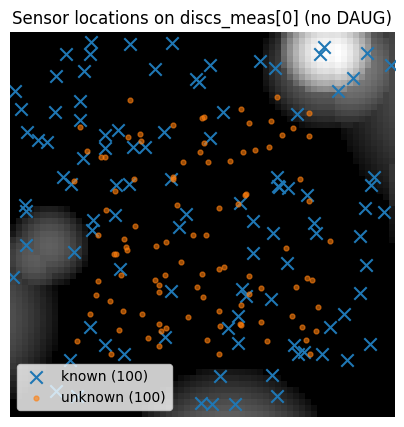

In [3]:
# Définition du problème
torch.manual_seed(0)

H = W = 64
N0 = 100 # nb de couples de coordonnées connues
N1 = 100 #nb de couples de coordonnées inconnues

# coordonnées connues :
margin = 0
torch.manual_seed(0)
known_coordinates = torch.stack([
    margin + torch.rand(N0, dtype=torch.float32) * (W - 1 - 2*margin),
    margin + torch.rand(N0, dtype=torch.float32) * (H - 1 - 2*margin),
], dim=1).contiguous()
# coordonnées inconnues : (inutilsables à l'entraînement)
margin = 10
unknown_coordinates = torch.stack([
    margin + torch.rand(N1, dtype=torch.float32) * (W - 1 - 2*margin),
    margin + torch.rand(N1, dtype=torch.float32) * (H - 1 - 2*margin),
], dim=1).contiguous()


ds = DatasetPB1(
    bs=8,
    known_coordinates=known_coordinates,
    unknown_coordinates=unknown_coordinates,
    steps_per_epoch=5,
    device="cpu",
)

batch = next(iter(ds))
# --- Overlay sensor locations on one measurement disc (sanity) ---
disc0 = batch["discs_gt"][0, 0].numpy()

plt.figure(figsize=(5,5))
plt.imshow(disc0, cmap="gray")
plt.scatter(known_coordinates[:,0].numpy(), known_coordinates[:,1].numpy(),
            s=80, marker="x", label="known (100)")
idx = torch.randperm(N1)[:200]
plt.scatter(unknown_coordinates[idx,0].numpy(), unknown_coordinates[idx,1].numpy(),
            s=12, alpha=0.6, label="unknown (100)")
plt.legend()
plt.title("Sensor locations on discs_meas[0] (no DAUG)")
plt.axis("off")
plt.show()

# Partie I : une première procédure d'apprentissage

Dans la cellule suivante sont codées deux fonctions qui font le lien entre une description par des mesures ponctuelles et un champ 2D. La première "gaussian_splat", prend en entrée des coordonnées et des mesures de capteurs puis construit dans un champ 2D de taille 64 x 64 comme une somme de noyaux gaussiens centrés sur les couples de coordonnées.\
La seconde, "project_field", prend en entrée un champ quelconque et des coordonnées, puis fournit les valeurs du champ aux coordonnées, en interpolant.


In [4]:
def gaussian_splat(meas_vals, coords_norm, H=64, W=64, sigma=2.0, radius=None, eps=1e-6):
    """
    meas_vals:  (B,N,1)  values
    coords_norm:(B,N,2)  normalized coords in [-1,1] (x,y)
    sigma: Gaussian std in *pixels*
    radius: kernel radius in pixels (default = ceil(3*sigma))
    Returns:
      img : (B,1,H,W)  normalized splat (value / weight)
      wsum: (B,1,H,W)  accumulated weights
    """
    B, N, _ = meas_vals.shape
    device = meas_vals.device
    dtype  = meas_vals.dtype

    if radius is None:
        radius = int(torch.ceil(torch.tensor(3.0 * sigma)).item())

    # normalized [-1,1] -> pixel [0,W-1]/[0,H-1]
    x = (coords_norm[..., 0] + 1.0) * (W - 1) / 2.0
    y = (coords_norm[..., 1] + 1.0) * (H - 1) / 2.0

    # keep finite; gradients outside can be weak anyway
    x = x.clamp(-1e6, 1e6)
    y = y.clamp(-1e6, 1e6)

    x0 = torch.floor(x).long()
    y0 = torch.floor(y).long()

    v = meas_vals[..., 0]  # (B,N)

    img  = torch.zeros(B, H*W, device=device, dtype=dtype)
    wsum = torch.zeros(B, H*W, device=device, dtype=dtype)

    # offsets in a (2r+1)x(2r+1) window
    offs = torch.arange(-radius, radius + 1, device=device)
    oy, ox = torch.meshgrid(offs, offs, indexing="ij")  # (K,K)
    ox = ox.reshape(-1)  # (K2,)
    oy = oy.reshape(-1)  # (K2,)
    K2 = ox.numel()

    # neighbor pixel indices for each point
    ix = x0.unsqueeze(-1) + ox.view(1, 1, K2)  # (B,N,K2)
    iy = y0.unsqueeze(-1) + oy.view(1, 1, K2)  # (B,N,K2)

    # distances (in pixels) to neighbor centers
    dx = x.unsqueeze(-1) - ix.to(dtype)  # (B,N,K2)
    dy = y.unsqueeze(-1) - iy.to(dtype)  # (B,N,K2)

    w = torch.exp(-(dx*dx + dy*dy) / (2.0 * (sigma**2)))  # (B,N,K2)

    # mask out-of-bounds neighbors
    inb = (ix >= 0) & (ix < W) & (iy >= 0) & (iy < H)
    w = w * inb.to(dtype)

    # flatten everything for scatter_add
    idx = (iy.clamp(0, H-1) * W + ix.clamp(0, W-1)).reshape(B, -1)  # (B, N*K2)
    w_flat = w.reshape(B, -1)                                       # (B, N*K2)
    v_flat = (v.unsqueeze(-1) * w).reshape(B, -1)                   # (B, N*K2)

    img.scatter_add_(1, idx, v_flat)
    wsum.scatter_add_(1, idx, w_flat)

    img  = img.view(B, 1, H, W)
    wsum = wsum.view(B, 1, H, W)
    img  = img / (wsum + eps)

    return img, wsum


def project_field(field, coords_norm):
    """
    field: (B,1,64,64)
    coords_norm: (B,N,2)
    """
    B = field.size(0)
    grid = coords_norm.view(B, 1, -1, 2)
    y = F.grid_sample(field, grid, align_corners=True, padding_mode="zeros")
    return y.squeeze(1).squeeze(1)  # (B,N)

**Q1** En quelques lignes de code :
- construire un champ 2D à partir de coordonnées/valeurs et représentez-le.
- justifier que torch parvient effectivement à calculer des gradients à travers ces fonctions.

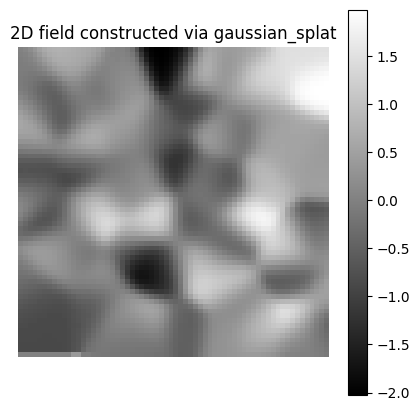

In [5]:
N = 100
coords = torch.stack([
    2*torch.rand(N, dtype=torch.float32)-1,
    2*torch.rand(N, dtype=torch.float32)-1,
], dim=1).contiguous()

# Génération de valeurs aléatoires pour chaque coordonnée
vals = torch.randn(N, dtype=torch.float32)
vals_reshaped = vals.unsqueeze(0).unsqueeze(-1) # Adds batch and channel dimensions
coords_reshaped = coords.unsqueeze(0) # Adds batch dimension

# Application de la fonction gaussian_splat
img, wsum = gaussian_splat(vals_reshaped, coords_reshaped, H, W, sigma=3)

# Affichage du champ reconstruit
plt.figure(figsize=(5,5))
plt.imshow(img[0, 0].cpu().numpy(), cmap="gray") # Display the first image in the batch and its first channel
plt.title("2D field constructed via gaussian_splat")
plt.colorbar()
plt.axis("off")
plt.show()

Dans la cellule suivante est précodée l'architecture de base, qui, à partir de valeurs mesurées par les deux-cents capteurs et des coordonnées connues sera susceptible de fournir un champ 2D candidat :

In [6]:
# ---- Generator: splat + 1 noise channel -> full UNet ----
class Generator(nn.Module):
    def __init__(self, N0, N1, d_model=64, n_heads=4, n_blocks=4,):
        super().__init__()
        self.N0 = N0
        self.N1 = N1
        self.N  = N0 + N1

        # ---- trainable unknown coordinates (normalized) ----
        self.unknown_coords = nn.Parameter(torch.empty(N1, 2).uniform_(-0.5, 0.5))

        # ---- UNet on (splat, noise) ----
        self.noise_alpha = 0.5
        self.unet = UNet64(in_ch=1, base=32, out_ch=1)

    def forward(self, meas_vals, known_coords_norm, sigma=2):
        """
        meas_vals: (B, N, 1) with -0.1 padding
        known_coords_norm: (N0,2) normalized
        mask(optional): (B,N,1) 1 present, 0 missing (if you want +0.1*mask trick)
        """
        B = meas_vals.size(0)
        device = meas_vals.device

        coords = torch.cat([
            known_coords_norm.unsqueeze(0).expand(B, -1, -1),
            self.unknown_coords.unsqueeze(0).expand(B, -1, -1)
        ], dim=1)  # (B,N,2)

        # Splatting: convert measurements and coordinates to a 2D field
        img_splat, _ = gaussian_splat(meas_vals, coords, H=64, W=64, sigma=sigma)

        # Pass the splatted image through the UNet
        field = self.unet(img_splat)

        return field # application de tanh pour restreindre l'intervalle de sortie

**Q2** Compléter le code en faisant se suivre le splatting et l'application du UNet. Vérifier sur un exemple que le code est bien fonctionnel.


Shape du champ généré: torch.Size([8, 1, 64, 64])
Valeurs min/max: -0.092 / -0.083


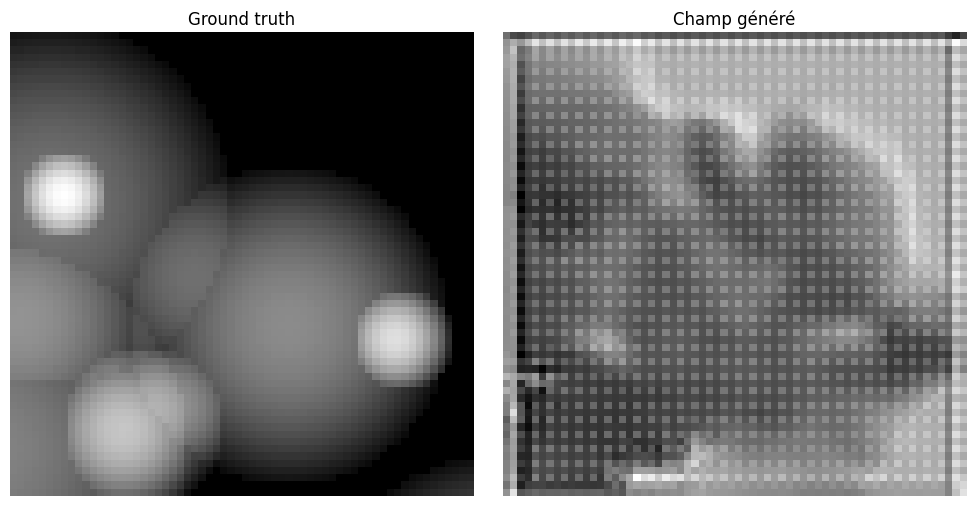

✓ Le générateur fonctionne correctement !


In [7]:
# Test du générateur
device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(N0, N1).to(device)

# Création d'un batch de test
batch_test = next(iter(ds))
meas_vals = torch.cat([batch_test["meas_known"], batch_test["meas_unknown"]], dim=2)
meas_vals = meas_vals[:,1,:].unsqueeze(-1).to(device)  # (B,N,1)

# Normalisation des coordonnées connues
known_coords_norm = 2.0 * known_coordinates / (W - 1) - 1.0  # (N0,2) in [-1,1]

# Forward pass
with torch.no_grad():
    field = G(meas_vals, known_coords_norm.to(device), sigma=2.0)

print(f"Shape du champ généré: {field.shape}")
print(f"Valeurs min/max: {field.min().item():.3f} / {field.max().item():.3f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(batch_test["discs_gt"][0, 0].numpy(), cmap="gray")
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(field[0, 0].cpu().numpy(), cmap="gray")
plt.title("Champ généré")
plt.axis("off")
plt.tight_layout()
plt.show()

print("✓ Le générateur fonctionne correctement !")

**Q3** Où sont les différents paramètres entraînables du générateur ? Préciser leur nombre pour chacun des attributs.

Les paramètres entraînables sont :
1. **self.unknown_coords** : un tenseur de paramètres (N1, 2) = (100, 2) = **200 paramètres**
   - Ce sont les coordonnées normalisées des capteurs inconnus
   
2. **self.unet** : le réseau UNet64 qui contient :
   - Conv2d et LeakyReLU dans les blocs DoubleConv
   - MaxPool2d (pas de paramètres)
   - ConvTranspose2d dans les upsampling
   - Conv2d final
   
   Calculons le nombre de paramètres du UNet :

In [8]:
# Calcul du nombre de paramètres
G_test = Generator(N0, N1)
total_params = sum(p.numel() for p in G_test.parameters())
trainable_params = sum(p.numel() for p in G_test.parameters() if p.requires_grad)

unknown_coords_params = G_test.unknown_coords.numel()
unet_params = sum(p.numel() for p in G_test.unet.parameters())

print(f"Paramètres unknown_coords: {unknown_coords_params}")
print(f"Paramètres UNet: {unet_params}")
print(f"Total paramètres: {total_params}")
print(f"Paramètres entraînables: {trainable_params}")

Paramètres unknown_coords: 200
Paramètres UNet: 2441121
Total paramètres: 2441321
Paramètres entraînables: 2441321


Dans la cellule suivante, on donne une amorce de boucle d'entraînement.
L'idée est de séparer chacun des batchs de 200 mesures mis à disposition, en un sous-ensemble de mesure d'entrée (proportion p_in) et un sous-ensemble de mesure cibles (proportion 1-p_in).

 epoch : 0


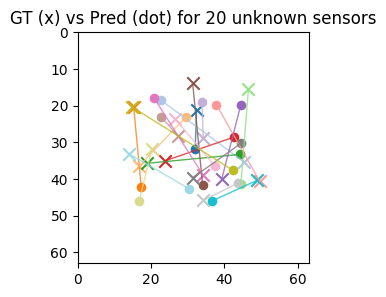

/tmp/ipython-input-1616879135.py:535: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


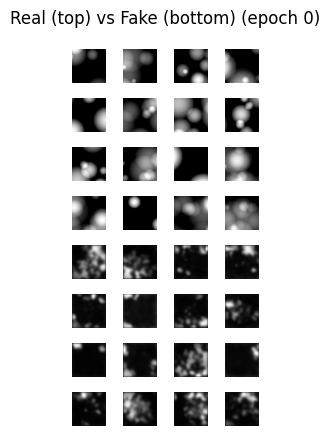

 epoch : 1
L2=0.0160, MAE=0.0922, Dist_median=21.14px, Dist_max=39.03px
 epoch : 2
 epoch : 3
L2=0.0138, MAE=0.0915, Dist_median=20.39px, Dist_max=39.15px
 epoch : 4
 epoch : 5
L2=0.0138, MAE=0.0949, Dist_median=20.46px, Dist_max=39.13px
 epoch : 6
 epoch : 7
L2=0.0130, MAE=0.0956, Dist_median=20.47px, Dist_max=38.84px
 epoch : 8
 epoch : 9
L2=0.0121, MAE=0.0960, Dist_median=20.61px, Dist_max=38.91px
 epoch : 10


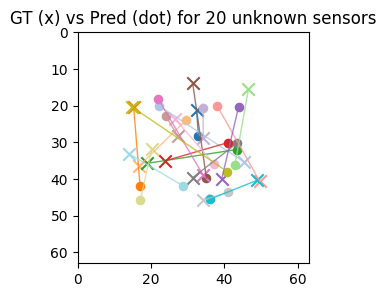

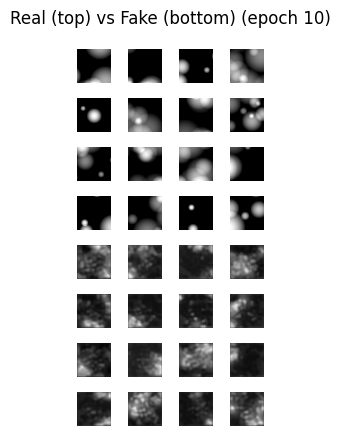

 epoch : 11
L2=0.0106, MAE=0.0924, Dist_median=20.42px, Dist_max=38.89px
 epoch : 12
 epoch : 13
L2=0.0107, MAE=0.0936, Dist_median=20.45px, Dist_max=38.67px
 epoch : 14
 epoch : 15
L2=0.0088, MAE=0.0893, Dist_median=20.27px, Dist_max=38.78px
 epoch : 16
 epoch : 17
L2=0.0073, MAE=0.0849, Dist_median=20.22px, Dist_max=38.91px
 epoch : 18
 epoch : 19
L2=0.0065, MAE=0.0835, Dist_median=20.15px, Dist_max=39.01px
 epoch : 20


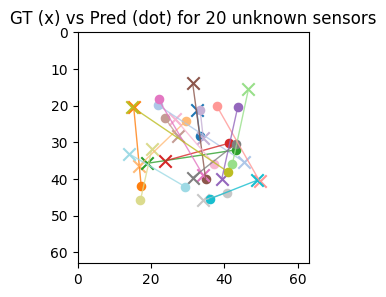

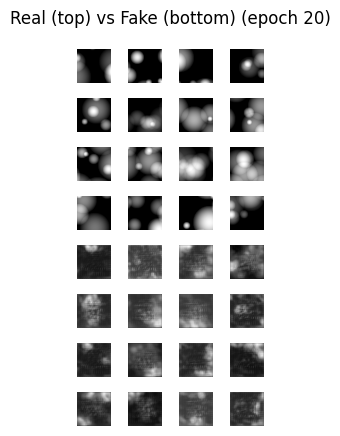

 epoch : 21
L2=0.0063, MAE=0.0825, Dist_median=20.06px, Dist_max=39.13px
 epoch : 22
 epoch : 23
L2=0.0058, MAE=0.0811, Dist_median=20.20px, Dist_max=39.03px
 epoch : 24
 epoch : 25
L2=0.0054, MAE=0.0807, Dist_median=20.05px, Dist_max=39.10px
 epoch : 26
 epoch : 27
L2=0.0052, MAE=0.0799, Dist_median=20.07px, Dist_max=39.01px
 epoch : 28
 epoch : 29
L2=0.0054, MAE=0.0813, Dist_median=20.00px, Dist_max=39.14px
 epoch : 30


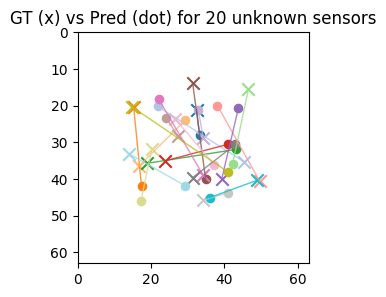

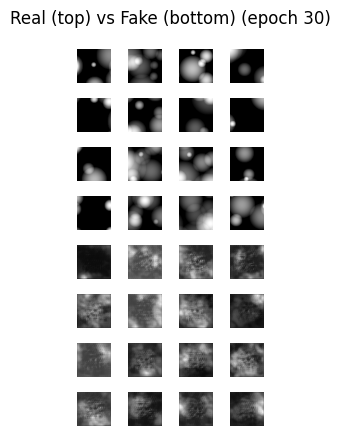

 epoch : 31
L2=0.0047, MAE=0.0800, Dist_median=20.04px, Dist_max=39.02px
 epoch : 32
 epoch : 33
L2=0.0046, MAE=0.0778, Dist_median=20.04px, Dist_max=39.03px
 epoch : 34
 epoch : 35
L2=0.0048, MAE=0.0789, Dist_median=19.97px, Dist_max=38.98px
 epoch : 36
 epoch : 37
L2=0.0044, MAE=0.0775, Dist_median=19.98px, Dist_max=38.99px
 epoch : 38
 epoch : 39
L2=0.0044, MAE=0.0777, Dist_median=19.96px, Dist_max=39.03px
 epoch : 40


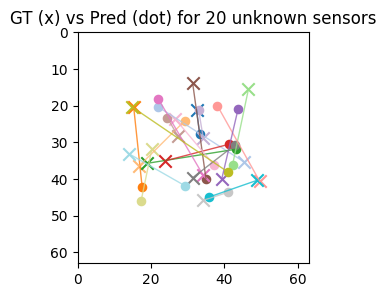

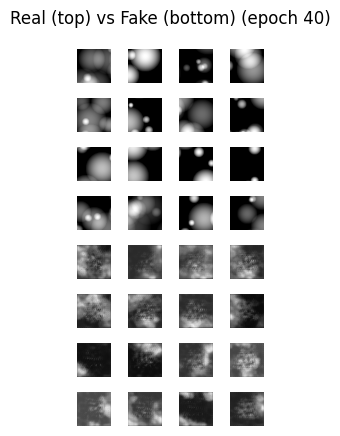

 epoch : 41
L2=0.0043, MAE=0.0769, Dist_median=19.96px, Dist_max=39.06px
 epoch : 42
 epoch : 43
L2=0.0041, MAE=0.0786, Dist_median=19.93px, Dist_max=39.06px
 epoch : 44
 epoch : 45
L2=0.0039, MAE=0.0768, Dist_median=19.98px, Dist_max=38.96px
 epoch : 46
 epoch : 47
L2=0.0042, MAE=0.0796, Dist_median=20.03px, Dist_max=38.90px
 epoch : 48
 epoch : 49
L2=0.0039, MAE=0.0773, Dist_median=19.99px, Dist_max=38.91px


In [15]:
# Initialisation
device = "cuda" if torch.cuda.is_available() else "cpu"
nepochs = 50
p_in = 0.5  # proportion de mesures utilisées en entrée
sigma = 2.0

# Normalisation des coordonnées connues
known_coords_norm = 2.0 * known_coordinates / (W - 1) - 1.0  # (N0,2) in [-1,1]

# Création du générateur et de l'optimiseur
G = Generator(N0, N1).to(device)
optG = torch.optim.Adam(G.parameters(), lr=1e-3)

ds = DatasetPB1(bs=32,
            known_coordinates=known_coordinates,
            unknown_coordinates=unknown_coordinates,
            steps_per_epoch=50,
            device=device)
# Stockage des scores pour la partie III
scores_history = {"l2": [], "mae": [], "dist_median": [], "dist_max": []}

for epoch in range(nepochs):
    print(f' epoch : {epoch}')
    # running sums for this epoch
    sum_l2 = 0.0
    sum_g  = 0.0
    sum_d  = 0.0
    n_steps = 0
    sum_mae = 0.0

    # Pas de DataLoader : on sollicite seulement le Dataset ds
    for batch in ds:
        # Récupération de l'ensemble des mesures disponibles
        meas = torch.cat([batch["meas_known"], batch["meas_unknown"]], dim=2)
        meas = meas[:,1,:].unsqueeze(-1).to(device)  # (B,N,1)

        # Masquage d'une partie des inputs (attention à la confusion valeurs nulles / valeurs masquées !)
        input_mask = (torch.rand_like(meas) < p_in).float()
        meas_in_shift = meas * input_mask + (-0.1) * (1 - input_mask)

        # Forward
        field = G(meas_in_shift, known_coords_norm.to(device), sigma)

        # Récupération des coordonnées normalisées
        coords_full = torch.cat([
            known_coords_norm.unsqueeze(0).expand(field.size(0), -1, -1).to(device),
            G.unknown_coords.unsqueeze(0).expand(field.size(0), -1, -1)
        ], dim=1)

        # PRojection
        proj_vals = project_field(field, coords_full)

        # Masque pour les cibles
        target_mask = (1 - input_mask.squeeze(-1))

        # Optim
        optG.zero_grad()
        loss_l2 = ((proj_vals - meas.squeeze(-1)) ** 2 * target_mask).sum() / (target_mask.sum() + 1e-6)
        loss_l2.backward()
        optG.step()

        # Calcul de la MAE sur le champ complet (pour monitoring)
        with torch.no_grad():
            mae_batch = (field - batch["discs_gt"].to(device)).abs().mean().item()
            sum_mae += mae_batch

        sum_l2 += loss_l2.item()
        n_steps += 1

    # Visualisation / Scoring (pas de validation)
    with torch.no_grad():
      # Calcul des distances entre coordonnées vraies et prédites
      pred_pix = (G.unknown_coords.detach().cpu() + 1.0) * ((W - 1) / 2.0)
      gt_pix = unknown_coordinates.detach().cpu()
      distances = torch.norm(pred_pix - gt_pix, dim=1)
      dist_median = distances.median().item()
      dist_max = distances.max().item()

      scores_history["l2"].append(sum_l2 / n_steps)
      scores_history["mae"].append(sum_mae / n_steps)
      scores_history["dist_median"].append(dist_median)
      scores_history["dist_max"].append(dist_max)

      if epoch % 10 == 0:
        viz_coords_pairs(
            unknown_coordinates=unknown_coordinates,
            unknown_coords_pred_norm=G.unknown_coords,
            N_viz=20,
            H=64, W=64
        )
        show_real_fake_grids(real=batch["discs_gan"], fake=field, n=16, title_suffix=f"(epoch {epoch})")

      if (epoch + 1) % 2 == 0:
            print(f"L2={scores_history['l2'][-1]:.4f}, MAE={scores_history['mae'][-1]:.4f}, "f"Dist_median={scores_history['dist_median'][-1]:.2f}px, Dist_max={scores_history['dist_max'][-1]:.2f}px")

**Q4** Compléter la boucle en suivant en tenant compte des éléments suivants :
- les valeurs sont toujours positives ou nulles. Il convient d'aider le générateur à bien différencier les valeurs nulles mesurées des valeurs qui sont masquées. Proposer une méthode qui le permette.

- à la fin de la boucle, afficher, en plus de la loss l2,  la distance médiane et le maximum des distances entre coordonnées vraies et coordonnées "prédites" pour les cents derniers points.

- afficher aussi la MAE entre le champ produit par le générateur et le champ à reconstituer.

**Q5** Pourquoi s'est-on passé de DataLoader et d'étape de validation dans cette boucle ?  


<span style="color:green">

On ne recourt pas ici à un DataLoader ni à une étape de validation car dans ce scénario "triché", le modèle connaît déjà les coordonnées inconnues réelles (`unknown_coords`), qui sont accessibles à chaque itération. De plus, les données utilisées sont générées dynamiquement à la volée à chaque batch, il n’y a donc ni dataset fixe à parcourir, ni échantillons réservés pour la validation.
</span>

**Q6** Instancier le modèle, régler self.unknown_coords sur les vraies coordonnées inconnues (i.e. tricher) et geler ce paramètre. Entraîner sur 100 époques pour vérifier que dans ce cas, on a convergence progressive de la loss l2 sur les valeurs, mais pas de la MAE globale. Expliquer pourquoi.

- La loss L2 converge car elle mesure l'erreur de reconstruction aux positions des capteurs.
  Avec les bonnes coordonnées, le modèle peut apprendre à reconstruire correctement aux bons endroits.
- La MAE globale ne converge pas car elle mesure l'erreur sur TOUT le champ 2D.
  Le modèle n'apprend qu'à reconstruire aux positions des capteurs (200 points),
  mais pas nécessairement à générer un champ 2D cohérent partout ailleurs.

Epoch 0: L2=0.0363, MAE=0.1491
Epoch 10: L2=0.0037, MAE=0.0569
Epoch 20: L2=0.0028, MAE=0.0558
Epoch 30: L2=0.0025, MAE=0.0582
Epoch 40: L2=0.0024, MAE=0.0604


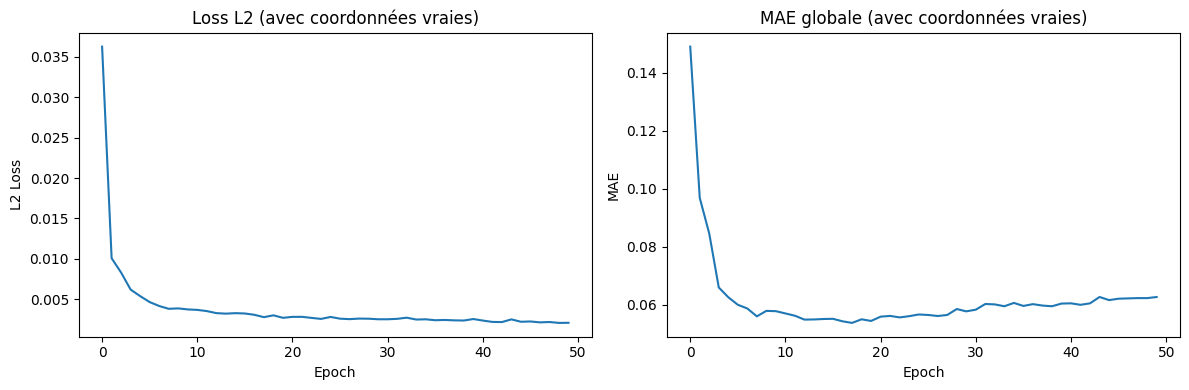


Explication :
- La loss L2 converge car elle mesure l'erreur de reconstruction aux positions des capteurs.
  Avec les bonnes coordonnées, le modèle peut apprendre à reconstruire correctement aux bons endroits.
- La MAE globale ne converge pas car elle mesure l'erreur sur TOUT le champ 2D.
  Le modèle n'apprend qu'à reconstruire aux positions des capteurs (200 points),
  mais pas nécessairement à générer un champ 2D cohérent partout ailleurs.


In [22]:
# Q6 : Test avec coordonnées vraies (triche)
device = "cuda" if torch.cuda.is_available() else "cpu"
nepochs = 50
p_in = 0.5
sigma = 2.0

known_coords_norm = 2.0 * known_coordinates / (W - 1) - 1.0

# Création du générateur
G_cheat = Generator(N0, N1).to(device)

# TRICHE : on initialise avec les vraies coordonnées
unknown_coords_norm_true = 2.0 * unknown_coordinates / (W - 1) - 1.0
with torch.no_grad():
    G_cheat.unknown_coords.data = unknown_coords_norm_true.to(device)

# GELER ce paramètre
G_cheat.unknown_coords.requires_grad = False

optG_cheat = torch.optim.Adam(
    [p for p in G_cheat.parameters() if p.requires_grad],
    lr=1e-3
)

ds = DatasetPB1(bs=32,
            known_coordinates=known_coordinates,
            unknown_coordinates=unknown_coordinates,
            steps_per_epoch=50,
            device=device)

scores_cheat = {"l2": [], "mae": []}

for epoch in range(nepochs):
    sum_l2 = 0.0
    sum_mae = 0.0
    n_steps = 0

    for batch in ds:
        meas = torch.cat([batch["meas_known"], batch["meas_unknown"]], dim=2)
        meas = meas[:,1,:].unsqueeze(-1).to(device)

        input_mask = (torch.rand_like(meas) < p_in).float()
        meas_in_shift = meas * input_mask + (-0.1) * (1 - input_mask)

        field = G_cheat(meas_in_shift, known_coords_norm.to(device), sigma)

        coords_full = torch.cat([
            known_coords_norm.to(device).unsqueeze(0).expand(field.size(0), -1, -1),
            G_cheat.unknown_coords.unsqueeze(0).expand(field.size(0), -1, -1)
        ], dim=1)

        proj_vals = project_field(field, coords_full)
        target_mask = (1 - input_mask.squeeze(-1))

        optG_cheat.zero_grad()
        loss_l2 = ((proj_vals - meas.squeeze(-1)) ** 2 * target_mask).sum() / (target_mask.sum() + 1e-6)
        loss_l2.backward()
        optG_cheat.step()

        with torch.no_grad():
            mae_batch = (field - batch["discs_gt"].to(device)).abs().mean().item()
            sum_mae += mae_batch

        sum_l2 += loss_l2.item()
        n_steps += 1

    scores_cheat["l2"].append(sum_l2 / n_steps)
    scores_cheat["mae"].append(sum_mae / n_steps)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: L2={sum_l2/n_steps:.4f}, MAE={sum_mae/n_steps:.4f}")

# Visualisation de l'évolution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(scores_cheat["l2"])
plt.title("Loss L2 (avec coordonnées vraies)")
plt.xlabel("Epoch")
plt.ylabel("L2 Loss")

plt.subplot(1, 2, 2)
plt.plot(scores_cheat["mae"])
plt.title("MAE globale (avec coordonnées vraies)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


**Q7** Maintenant, reprendre l'entraînement sans tricher ni geler le tenseur self.unknown_coords. Le modèle parvient-il a apprendre les bonnes coordonnées ? Pour quelles raisons à votre avis ?

Epoch 0: L2=0.0641, MAE=0.1461
Epoch 10: L2=0.0155, MAE=0.0916
Epoch 20: L2=0.0134, MAE=0.0888
Epoch 30: L2=0.0115, MAE=0.0894
Epoch 40: L2=0.0104, MAE=0.0926


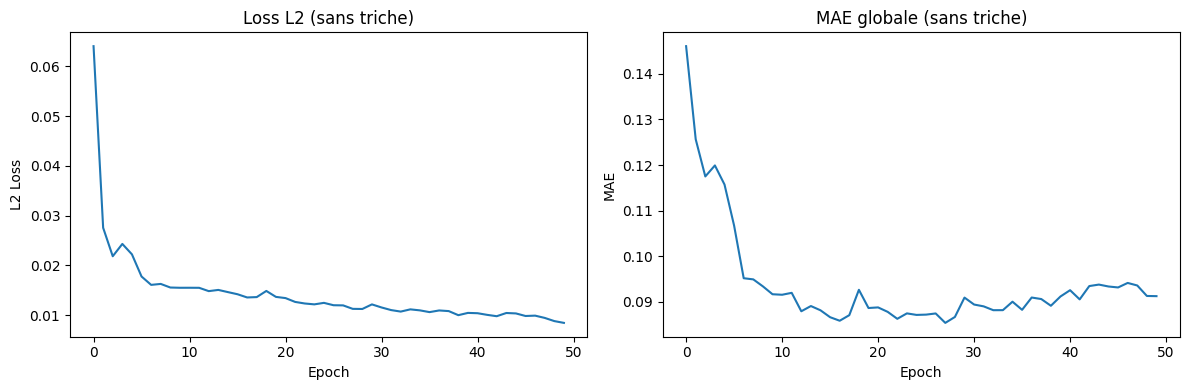

In [26]:
# Q7 : entraînement sans triche (unknown_coords non initialisées, non gelées)
device = "cuda" if torch.cuda.is_available() else "cpu"
nepochs = 50
p_in = 0.5
sigma = 2.0

known_coords_norm = 2.0 * known_coordinates / (W - 1) - 1.0

# Création du générateur
G = Generator(N0, N1).to(device)
# (on n'initialise PAS G.unknown_coords avec la vérité)
# (on laisse G.unknown_coords.requires_grad = True)

optG = torch.optim.Adam(
    [p for p in G.parameters() if p.requires_grad],
    lr=1e-3
)

ds = DatasetPB1(bs=32,
            known_coordinates=known_coordinates,
            unknown_coordinates=unknown_coordinates,
            steps_per_epoch=50,
            device=device)

scores_no_cheat = {"l2": [], "mae": []}

for epoch in range(nepochs):
    sum_l2 = 0.0
    sum_mae = 0.0
    n_steps = 0

    for batch in ds:
        meas = torch.cat([batch["meas_known"], batch["meas_unknown"]], dim=2)
        meas = meas[:,1,:].unsqueeze(-1).to(device)

        input_mask = (torch.rand_like(meas) < p_in).float()
        meas_in_shift = meas * input_mask + (-0.1) * (1 - input_mask)

        field = G(meas_in_shift, known_coords_norm.to(device), sigma)

        coords_full = torch.cat([
            known_coords_norm.to(device).unsqueeze(0).expand(field.size(0), -1, -1),
            G.unknown_coords.unsqueeze(0).expand(field.size(0), -1, -1)
        ], dim=1)

        proj_vals = project_field(field, coords_full)
        target_mask = (1 - input_mask.squeeze(-1))

        optG.zero_grad()
        loss_l2 = ((proj_vals - meas.squeeze(-1)) ** 2 * target_mask).sum() / (target_mask.sum() + 1e-6)
        loss_l2.backward()
        optG.step()

        with torch.no_grad():
            mae_batch = (field - batch["discs_gt"].to(device)).abs().mean().item()
            sum_mae += mae_batch

        sum_l2 += loss_l2.item()
        n_steps += 1

    scores_no_cheat["l2"].append(sum_l2 / n_steps)
    scores_no_cheat["mae"].append(sum_mae / n_steps)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: L2={sum_l2/n_steps:.4f}, MAE={sum_mae/n_steps:.4f}")

# Visualisation de l'évolution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(scores_no_cheat["l2"])
plt.title("Loss L2 (sans triche)")
plt.xlabel("Epoch")
plt.ylabel("L2 Loss")

plt.subplot(1, 2, 2)
plt.plot(scores_no_cheat["mae"])
plt.title("MAE globale (sans triche)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


**Q8** Pour espérer voir un début de convergence, il faut régler finement la procédure d'apprentissage. Ré-essayer avec les hyperparamètres ci-dessous,  et commentez :
- le choix du learning rate pour G.unknown_coords
- la réduction de p_in
- l'augmentation de sigma


In [23]:
G = Generator(N0, N1).to(device)

optG = torch.optim.Adam([
    {"params": [G.unknown_coords], "lr": 0.025, "betas": (0.1, 0.1)},
    {"params": [p for n,p in G.named_parameters() if n != "unknown_coords"], "lr": 2e-4},
], betas=(0.5, 0.9))

p_in = 0.3
sigma = 4

# Q7 : entraînement sans triche (unknown_coords non initialisées, non gelées)
device = "cuda" if torch.cuda.is_available() else "cpu"
nepochs = 50

known_coords_norm = 2.0 * known_coordinates / (W - 1) - 1.0

# Création du générateur
G = Generator(N0, N1).to(device)
# (on n'initialise PAS G.unknown_coords avec la vérité)
# (on laisse G.unknown_coords.requires_grad = True)

optG = torch.optim.Adam(
    [p for p in G.parameters() if p.requires_grad],
    lr=1e-3
)

ds = DatasetPB1(bs=32,
            known_coordinates=known_coordinates,
            unknown_coordinates=unknown_coordinates,
            steps_per_epoch=50,
            device=device)

scores_no_cheat = {"l2": [], "mae": []}

for epoch in range(nepochs):
    sum_l2 = 0.0
    sum_mae = 0.0
    n_steps = 0

    for batch in ds:
        meas = torch.cat([batch["meas_known"], batch["meas_unknown"]], dim=2)
        meas = meas[:,1,:].unsqueeze(-1).to(device)

        input_mask = (torch.rand_like(meas) < p_in).float()
        meas_in_shift = meas * input_mask + (-0.1) * (1 - input_mask)

        field = G(meas_in_shift, known_coords_norm.to(device), sigma)

        coords_full = torch.cat([
            known_coords_norm.to(device).unsqueeze(0).expand(field.size(0), -1, -1),
            G.unknown_coords.unsqueeze(0).expand(field.size(0), -1, -1)
        ], dim=1)

        proj_vals = project_field(field, coords_full)
        target_mask = (1 - input_mask.squeeze(-1))

        optG.zero_grad()
        loss_l2 = ((proj_vals - meas.squeeze(-1)) ** 2 * target_mask).sum() / (target_mask.sum() + 1e-6)
        loss_l2.backward()
        optG.step()

        with torch.no_grad():
            mae_batch = (field - batch["discs_gt"].to(device)).abs().mean().item()
            sum_mae += mae_batch

        sum_l2 += loss_l2.item()
        n_steps += 1

    scores_no_cheat["l2"].append(sum_l2 / n_steps)
    scores_no_cheat["mae"].append(sum_mae / n_steps)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: L2={sum_l2/n_steps:.4f}, MAE={sum_mae/n_steps:.4f}")

# Visualisation de l'évolution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(scores_no_cheat["l2"])
plt.title("Loss L2 (sans triche)")
plt.xlabel("Epoch")
plt.ylabel("L2 Loss")

plt.subplot(1, 2, 2)
plt.plot(scores_no_cheat["mae"])
plt.title("MAE globale (sans triche)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


**Q9** Un autre problème important tient à la divergence des paramètres. Ajouter la fonction de coût suivante, ré-entraînez, et commenter.

<span style="color:green">
Commentaire sur coord_hinge_loss :
Cette contrainte empêche les coordonnées de diverger vers des valeurs extrêmes.
Elle maintient les coordonnées dans une plage raisonnable [-0.8, 0.8] (environ [10, 54] pixels).
Cela stabilise l'entraînement et évite que certaines coordonnées s'échappent complètement. <span>

In [32]:
def coord_hinge_loss(coords):
    return (
        F.relu(coords - 0.8).mean() +
        F.relu(-coords - 0.8).mean()
    )
# Q9 : Ajout de la contrainte coord_hinge_loss
device = "cuda" if torch.cuda.is_available() else "cpu"
nepochs = 50
p_in = 0.3
sigma = 4
lambda_hinge = 0.1  # Poids de la contrainte

known_coords_norm = 2.0 * known_coordinates / (W - 1) - 1.0

G = Generator(N0, N1).to(device)

optG = torch.optim.Adam([
    {"params": [G.unknown_coords], "lr": 0.025, "betas": (0.1, 0.1)},
    {"params": [p for n,p in G.named_parameters() if n != "unknown_coords"], "lr": 2e-4},
], betas=(0.5, 0.9))

ds = DatasetPB1(bs=32,
            known_coordinates=known_coordinates,
            unknown_coordinates=unknown_coordinates,
            steps_per_epoch=50,
            device=device)

scores_history_q9 = {"l2": [], "mae": [], "dist_median": [], "dist_max": [], "hinge": []}

for epoch in range(nepochs):
    sum_l2 = 0.0
    sum_mae = 0.0
    sum_hinge = 0.0
    n_steps = 0

    for batch in ds:
        meas = torch.cat([batch["meas_known"], batch["meas_unknown"]], dim=2)
        meas = meas[:,1,:].unsqueeze(-1).to(device)

        input_mask = (torch.rand_like(meas) < p_in).float()
        meas_in_shift = meas * input_mask + (-0.1) * (1 - input_mask)

        field = G(meas_in_shift, known_coords_norm.to(device), sigma)

        coords_full = torch.cat([
            known_coords_norm.to(device).unsqueeze(0).expand(field.size(0), -1, -1),
            G.unknown_coords.unsqueeze(0).expand(field.size(0), -1, -1)
        ], dim=1)

        proj_vals = project_field(field, coords_full)
        target_mask = (1 - input_mask.squeeze(-1))

        optG.zero_grad()
        loss_l2 = ((proj_vals - meas.squeeze(-1)) ** 2 * target_mask).sum() / (target_mask.sum() + 1e-6)
        loss_hinge = coord_hinge_loss(G.unknown_coords)
        loss_total = loss_l2 + lambda_hinge * loss_hinge
        loss_total.backward()
        optG.step()

        with torch.no_grad():
            mae_batch = (field - batch["discs_gt"].to(device)).abs().mean().item()
            sum_mae += mae_batch
            sum_hinge += loss_hinge.item()

        sum_l2 += loss_l2.item()
        n_steps += 1

    with torch.no_grad():
        pred_pix = (G.unknown_coords.detach().cpu() + 1.0) * ((W - 1) / 2.0)
        gt_pix = unknown_coordinates.detach().cpu()
        distances = torch.norm(pred_pix - gt_pix, dim=1)
        dist_median = distances.median().item()
        dist_max = distances.max().item()

        scores_history_q9["l2"].append(sum_l2 / n_steps)
        scores_history_q9["mae"].append(sum_mae / n_steps)
        scores_history_q9["dist_median"].append(dist_median)
        scores_history_q9["dist_max"].append(dist_max)
        scores_history_q9["hinge"].append(sum_hinge / n_steps)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: L2={sum_l2/n_steps:.4f}, MAE={sum_mae/n_steps:.4f}, "
                  f"Hinge={sum_hinge/n_steps:.4f}, Dist_median={dist_median:.2f}px, Dist_max={dist_max:.2f}px")

Epoch 0: L2=0.0268, MAE=0.1220, Hinge=0.0000, Dist_median=16.31px, Dist_max=36.50px


**Q10** Parvenez-vous à réduire la distance max ? Faire plusieurs essais en retouchant éventuellement vos hyperparamètres pour passer sous 5 pixels (au moins pour la distance médiane). Gardez en mémoire la série temporelle des scores de votre meilleur version pour comparaison ultérieure (partie III).

Epoch 0: L2=0.0278, MAE=0.1309, Dist_median=11.50px, Dist_max=38.87px
Epoch 10: L2=0.0107, MAE=0.0810, Dist_median=2.15px, Dist_max=7.07px
Epoch 20: L2=0.0104, MAE=0.0789, Dist_median=2.16px, Dist_max=5.12px
Epoch 30: L2=0.0097, MAE=0.0757, Dist_median=2.21px, Dist_max=6.59px
Epoch 40: L2=0.0094, MAE=0.0742, Dist_median=2.28px, Dist_max=7.53px
Epoch 50: L2=0.0093, MAE=0.0732, Dist_median=2.70px, Dist_max=9.00px


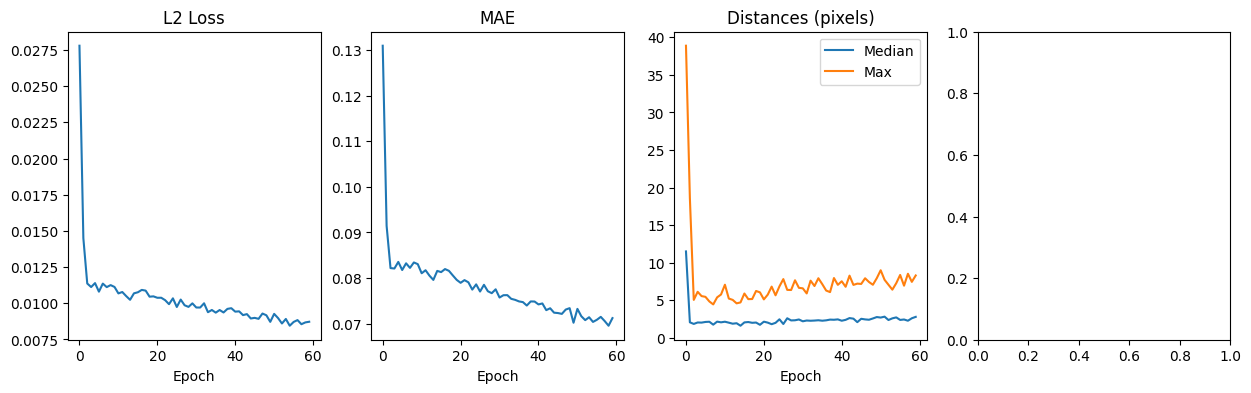

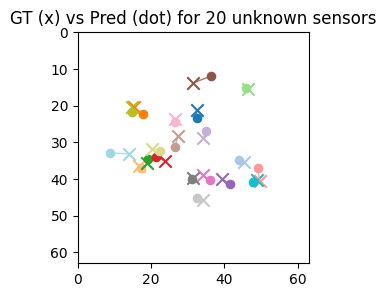

<Figure size 640x480 with 0 Axes>


Résultats finaux:
Distance médiane: 2.80 pixels
Distance max: 8.31 pixels
L2: 0.0087
MAE: 0.0712


In [36]:
# Q10 : Optimisation pour réduire la distance max sous 5 pixels
# On peut essayer différents hyperparamètres

device = "cuda" if torch.cuda.is_available() else "cpu"
nepochs = 60  # Plus d'époques
p_in = 0.25   # Encore moins de mesures en entrée
sigma = 5.0   # Sigma encore plus grand
lambda_hinge = 0.2  # Contrainte plus forte

known_coords_norm = 2.0 * known_coordinates / (W - 1) - 1.0

G_best = Generator(N0, N1).to(device)

# Learning rates encore plus ajustés
optG_best = torch.optim.Adam([
    {"params": [G_best.unknown_coords], "lr": 0.03, "betas": (0.1, 0.1)},
    {"params": [p for n,p in G_best.named_parameters() if n != "unknown_coords"], "lr": 1e-4},
], betas=(0.5, 0.9))

ds = DatasetPB1(bs=32,
            known_coordinates=known_coordinates,
            unknown_coordinates=unknown_coordinates,
            steps_per_epoch=50,
            device=device)

scores_best = {"l2": [], "mae": [], "dist_median": [], "dist_max": []}

for epoch in range(nepochs):
    sum_l2 = 0.0
    sum_mae = 0.0
    n_steps = 0

    for batch in ds:
        meas = torch.cat([batch["meas_known"], batch["meas_unknown"]], dim=2)
        meas = meas[:,1,:].unsqueeze(-1).to(device)

        input_mask = (torch.rand_like(meas) < p_in).float()
        meas_in_shift = meas * input_mask + (-0.1) * (1 - input_mask)

        field = G_best(meas_in_shift, known_coords_norm.to(device), sigma)

        coords_full = torch.cat([
            known_coords_norm.to(device).unsqueeze(0).expand(field.size(0), -1, -1),
            G_best.unknown_coords.unsqueeze(0).expand(field.size(0), -1, -1)
        ], dim=1)

        proj_vals = project_field(field, coords_full)
        target_mask = (1 - input_mask.squeeze(-1))

        optG_best.zero_grad()
        loss_l2 = ((proj_vals - meas.squeeze(-1)) ** 2 * target_mask).sum() / (target_mask.sum() + 1e-6)
        loss_hinge = coord_hinge_loss(G_best.unknown_coords)
        loss_total = loss_l2 + lambda_hinge * loss_hinge
        loss_total.backward()
        optG_best.step()

        with torch.no_grad():
            mae_batch = (field - batch["discs_gt"].to(device)).abs().mean().item()
            sum_mae += mae_batch

        sum_l2 += loss_l2.item()
        n_steps += 1

    with torch.no_grad():
        pred_pix = (G_best.unknown_coords.detach().cpu() + 1.0) * ((W - 1) / 2.0)
        gt_pix = unknown_coordinates.detach().cpu()
        distances = torch.norm(pred_pix - gt_pix, dim=1)
        dist_median = distances.median().item()
        dist_max = distances.max().item()

        scores_best["l2"].append(sum_l2 / n_steps)
        scores_best["mae"].append(sum_mae / n_steps)
        scores_best["dist_median"].append(dist_median)
        scores_best["dist_max"].append(dist_max)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: L2={sum_l2/n_steps:.4f}, MAE={sum_mae/n_steps:.4f}, "
                  f"Dist_median={dist_median:.2f}px, Dist_max={dist_max:.2f}px")

# Visualisation finale
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.plot(scores_best["l2"])
plt.title("L2 Loss")
plt.xlabel("Epoch")

plt.subplot(1, 4, 2)
plt.plot(scores_best["mae"])
plt.title("MAE")
plt.xlabel("Epoch")

plt.subplot(1, 4, 3)
plt.plot(scores_best["dist_median"], label="Median")
plt.plot(scores_best["dist_max"], label="Max")
plt.title("Distances (pixels)")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 4, 4)
viz_coords_pairs(
    unknown_coordinates=unknown_coordinates,
    unknown_coords_pred_norm=G_best.unknown_coords,
    N_viz=20,
    H=64, W=64
)
plt.tight_layout()
plt.show()

print(f"\nRésultats finaux:")
print(f"Distance médiane: {scores_best['dist_median'][-1]:.2f} pixels")
print(f"Distance max: {scores_best['dist_max'][-1]:.2f} pixels")
print(f"L2: {scores_best['l2'][-1]:.4f}")
print(f"MAE: {scores_best['mae'][-1]:.4f}")

# Sauvegarde pour partie III
scores_part1 = scores_best.copy()

**Q11** Conclure sur cette première version. En dehors de la piste qui sera suivie dans les parties suivantes, que feriez-vous pour l'améliorer ?

# Partie II

Dans cette partie, on essaie seulement d'implémenter un GAN à partir de batch['discs_gan'] et du générateur codé dans la partie I.
Les consignes sont les suivantes.

- Modifier le générateur : créer un bruit blanc gaussien à l'intérieur de la fonction forward, le placer en entrée du UNet à la place de la sortie du splatting.
- Créer un discriminateur. Vous pourrez reprendre l'architecture vue au TP n°6.
- Créer une boucle d'apprentissage. Reprendre les étapes standards du GAN (passer le discriminateur sur la sortie du générateur et sur batch['discs_gan'] alternativement en vous inspirant du TP n°6).
- Parvenir ainsi, en quelques dizaines d'époques à simuler des champs 2D proches de la réalité.
- Vérifier quantitativement en comparant les statistiques d'ordre 1 et 2 à l'échelle du pixel.

Starting GAN Training...
[0/50][0/50]	Loss_D: 1.3864	Loss_G: 0.6944
[0/50][10/50]	Loss_D: 1.3829	Loss_G: 0.7005
[0/50][20/50]	Loss_D: 1.3375	Loss_G: 0.7645
[0/50][30/50]	Loss_D: 1.0100	Loss_G: 0.5293
[0/50][40/50]	Loss_D: 1.0937	Loss_G: 0.5497


/tmp/ipython-input-1616879135.py:535: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


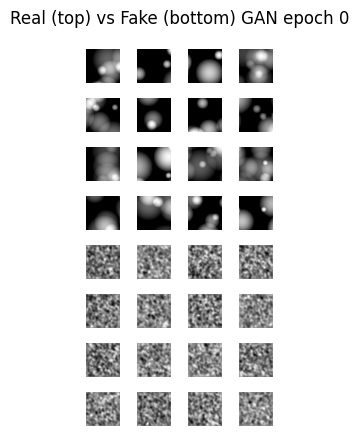

[1/50][0/50]	Loss_D: 1.4068	Loss_G: 0.5797
[1/50][10/50]	Loss_D: 1.1985	Loss_G: 0.9304
[1/50][20/50]	Loss_D: 0.9116	Loss_G: 1.3738
[1/50][30/50]	Loss_D: 0.7807	Loss_G: 0.8090
[1/50][40/50]	Loss_D: 0.7345	Loss_G: 0.7412
[2/50][0/50]	Loss_D: 0.7840	Loss_G: 0.6120
[2/50][10/50]	Loss_D: 0.7395	Loss_G: 0.7316
[2/50][20/50]	Loss_D: 0.7426	Loss_G: 0.9261
[2/50][30/50]	Loss_D: 0.6252	Loss_G: 1.0494
[2/50][40/50]	Loss_D: 0.6514	Loss_G: 0.7917
[3/50][0/50]	Loss_D: 1.6464	Loss_G: 4.6263
[3/50][10/50]	Loss_D: 0.6733	Loss_G: 0.7983
[3/50][20/50]	Loss_D: 0.5465	Loss_G: 0.9490
[3/50][30/50]	Loss_D: 0.5395	Loss_G: 1.2763
[3/50][40/50]	Loss_D: 0.5167	Loss_G: 1.0292
[4/50][0/50]	Loss_D: 0.6186	Loss_G: 0.8016
[4/50][10/50]	Loss_D: 0.6279	Loss_G: 0.7966
[4/50][20/50]	Loss_D: 0.5578	Loss_G: 0.8931
[4/50][30/50]	Loss_D: 0.2805	Loss_G: 1.4611
[4/50][40/50]	Loss_D: 0.4164	Loss_G: 1.2166
[5/50][0/50]	Loss_D: 0.5260	Loss_G: 0.9292
[5/50][10/50]	Loss_D: 0.4785	Loss_G: 0.9713
[5/50][20/50]	Loss_D: 0.4723	Loss_G: 

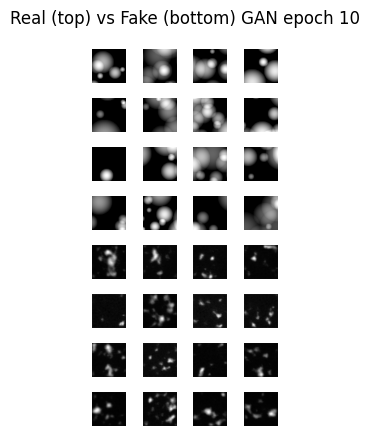

[11/50][0/50]	Loss_D: 1.0232	Loss_G: 0.6003
[11/50][10/50]	Loss_D: 1.1771	Loss_G: 0.5150
[11/50][20/50]	Loss_D: 0.9801	Loss_G: 0.6272
[11/50][30/50]	Loss_D: 0.8720	Loss_G: 0.6554
[11/50][40/50]	Loss_D: 1.3048	Loss_G: 1.0595
[12/50][0/50]	Loss_D: 0.6775	Loss_G: 0.7812
[12/50][10/50]	Loss_D: 0.7156	Loss_G: 0.7726
[12/50][20/50]	Loss_D: 0.7343	Loss_G: 0.7268
[12/50][30/50]	Loss_D: 0.6929	Loss_G: 0.7147
[12/50][40/50]	Loss_D: 0.7577	Loss_G: 0.7093
[13/50][0/50]	Loss_D: 0.7202	Loss_G: 0.7087
[13/50][10/50]	Loss_D: 0.6998	Loss_G: 0.7109
[13/50][20/50]	Loss_D: 0.7032	Loss_G: 0.7111
[13/50][30/50]	Loss_D: 0.6923	Loss_G: 0.7121
[13/50][40/50]	Loss_D: 0.6946	Loss_G: 0.7096
[14/50][0/50]	Loss_D: 0.7040	Loss_G: 0.6952
[14/50][10/50]	Loss_D: 0.4418	Loss_G: 1.1105
[14/50][20/50]	Loss_D: 0.6410	Loss_G: 0.8235
[14/50][30/50]	Loss_D: 0.6662	Loss_G: 0.7295
[14/50][40/50]	Loss_D: 0.6923	Loss_G: 0.7229
[15/50][0/50]	Loss_D: 0.6675	Loss_G: 0.7238
[15/50][10/50]	Loss_D: 0.6666	Loss_G: 0.7240
[15/50][20/50]	

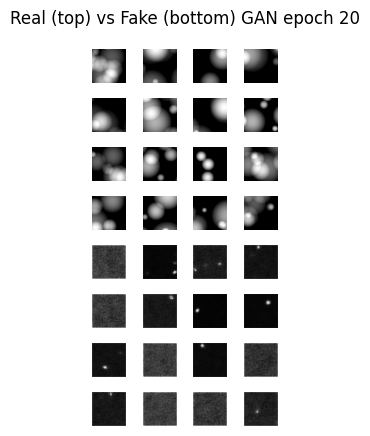

[21/50][0/50]	Loss_D: 0.6897	Loss_G: 0.7359
[21/50][10/50]	Loss_D: 0.6553	Loss_G: 0.7423
[21/50][20/50]	Loss_D: 0.6992	Loss_G: 0.7498
[21/50][30/50]	Loss_D: 0.6741	Loss_G: 0.7271
[21/50][40/50]	Loss_D: 0.6655	Loss_G: 0.7400
[22/50][0/50]	Loss_D: 0.6850	Loss_G: 0.7439
[22/50][10/50]	Loss_D: 0.7016	Loss_G: 0.7451
[22/50][20/50]	Loss_D: 0.6678	Loss_G: 0.7319
[22/50][30/50]	Loss_D: 0.6909	Loss_G: 0.7300
[22/50][40/50]	Loss_D: 0.7334	Loss_G: 0.7232
[23/50][0/50]	Loss_D: 0.6711	Loss_G: 0.7344
[23/50][10/50]	Loss_D: 0.6858	Loss_G: 0.7370
[23/50][20/50]	Loss_D: 0.6533	Loss_G: 0.7545
[23/50][30/50]	Loss_D: 0.6784	Loss_G: 0.7474
[23/50][40/50]	Loss_D: 0.7934	Loss_G: 0.6813
[24/50][0/50]	Loss_D: 0.7347	Loss_G: 0.8042
[24/50][10/50]	Loss_D: 0.7592	Loss_G: 0.5356
[24/50][20/50]	Loss_D: 0.1814	Loss_G: 1.9822
[24/50][30/50]	Loss_D: 0.1580	Loss_G: 2.0488
[24/50][40/50]	Loss_D: 0.1735	Loss_G: 2.0414
[25/50][0/50]	Loss_D: 0.4247	Loss_G: 1.1083
[25/50][10/50]	Loss_D: 0.4750	Loss_G: 1.0096
[25/50][20/50]	

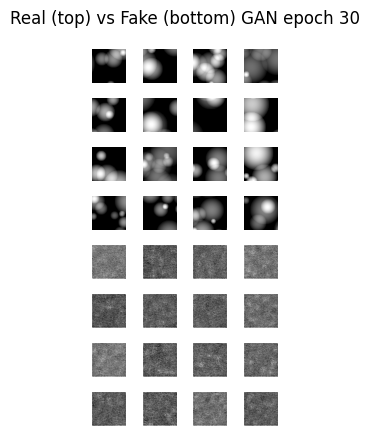

[31/50][0/50]	Loss_D: 0.6393	Loss_G: 0.7394
[31/50][10/50]	Loss_D: 0.6672	Loss_G: 0.7231
[31/50][20/50]	Loss_D: 0.6827	Loss_G: 0.7278
[31/50][30/50]	Loss_D: 0.6821	Loss_G: 0.7297
[31/50][40/50]	Loss_D: 0.6604	Loss_G: 0.7420
[32/50][0/50]	Loss_D: 0.5533	Loss_G: 0.8587
[32/50][10/50]	Loss_D: 0.5639	Loss_G: 0.9023
[32/50][20/50]	Loss_D: 0.6637	Loss_G: 0.7260
[32/50][30/50]	Loss_D: 0.6247	Loss_G: 0.7669
[32/50][40/50]	Loss_D: 0.6388	Loss_G: 0.7733
[33/50][0/50]	Loss_D: 0.6747	Loss_G: 0.7171
[33/50][10/50]	Loss_D: 0.6481	Loss_G: 0.7427
[33/50][20/50]	Loss_D: 0.5019	Loss_G: 0.9408
[33/50][30/50]	Loss_D: 0.6627	Loss_G: 0.7348
[33/50][40/50]	Loss_D: 0.5426	Loss_G: 0.8858
[34/50][0/50]	Loss_D: 0.6722	Loss_G: 0.7476
[34/50][10/50]	Loss_D: 0.5387	Loss_G: 0.8741
[34/50][20/50]	Loss_D: 0.6741	Loss_G: 0.7431
[34/50][30/50]	Loss_D: 0.6639	Loss_G: 0.7495
[34/50][40/50]	Loss_D: 0.6558	Loss_G: 0.7264
[35/50][0/50]	Loss_D: 0.6414	Loss_G: 0.7533
[35/50][10/50]	Loss_D: 1.1278	Loss_G: 0.7483
[35/50][20/50]	

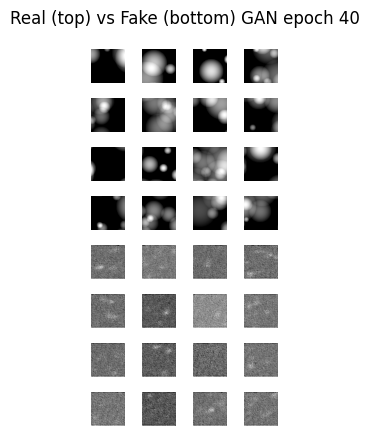

[41/50][0/50]	Loss_D: 0.6896	Loss_G: 0.6973
[41/50][10/50]	Loss_D: 0.7867	Loss_G: 0.6198
[41/50][20/50]	Loss_D: 0.8213	Loss_G: 0.6111
[41/50][30/50]	Loss_D: 1.0496	Loss_G: 0.5329
[41/50][40/50]	Loss_D: 0.9480	Loss_G: 0.5548
[42/50][0/50]	Loss_D: 1.0378	Loss_G: 0.5415
[42/50][10/50]	Loss_D: 0.7590	Loss_G: 0.6988
[42/50][20/50]	Loss_D: 0.7377	Loss_G: 0.6928
[42/50][30/50]	Loss_D: 0.7108	Loss_G: 0.6884
[42/50][40/50]	Loss_D: 0.7102	Loss_G: 0.6840
[43/50][0/50]	Loss_D: 0.7208	Loss_G: 0.6717
[43/50][10/50]	Loss_D: 0.6516	Loss_G: 0.7862
[43/50][20/50]	Loss_D: 0.5881	Loss_G: 0.8725
[43/50][30/50]	Loss_D: 0.6916	Loss_G: 0.7061
[43/50][40/50]	Loss_D: 0.7094	Loss_G: 0.7094
[44/50][0/50]	Loss_D: 0.6749	Loss_G: 0.7164
[44/50][10/50]	Loss_D: 0.6898	Loss_G: 0.6977
[44/50][20/50]	Loss_D: 0.7001	Loss_G: 0.6960
[44/50][30/50]	Loss_D: 0.6971	Loss_G: 0.6932
[44/50][40/50]	Loss_D: 0.7021	Loss_G: 0.6899
[45/50][0/50]	Loss_D: 0.8139	Loss_G: 0.6082
[45/50][10/50]	Loss_D: 0.7090	Loss_G: 0.7263
[45/50][20/50]	

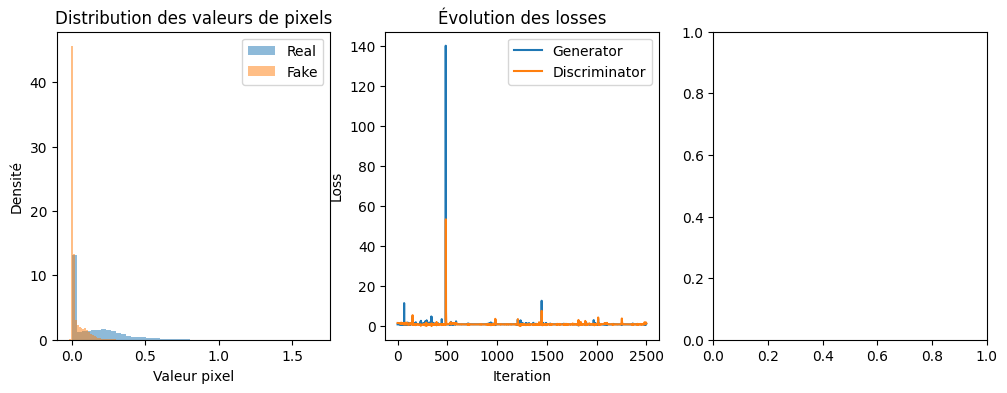

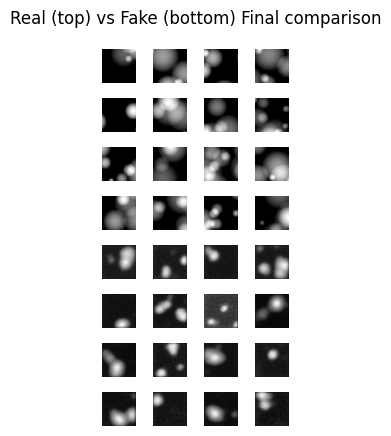

<Figure size 640x480 with 0 Axes>

In [37]:
class GeneratorGAN(nn.Module):
    def __init__(self, N0, N1, d_model=64, n_heads=4, n_blocks=4,):
        super().__init__()
        self.N0 = N0
        self.N1 = N1
        self.N  = N0 + N1

        # UNet qui prend du bruit en entrée
        self.unet = UNet64(in_ch=1, base=32, out_ch=1)

    def forward(self, z):
        """
        z: (B,1,H,W) bruit gaussien
        """
        field = self.unet(z)
        return 2*torch.tanh(field)

# 2. Créer un discriminateur (inspiré du TP6)
nc = 1
ndf = 32

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, input):
        return self.main(input).view(-1)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# 3. Boucle d'apprentissage GAN
device = "cuda" if torch.cuda.is_available() else "cpu"
nepochs = 50
lr = 2e-4
beta1 = 0.5

netG = GeneratorGAN(N0, N1).to(device)
netD = Discriminator().to(device)

netD.apply(weights_init)

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

criterion = nn.BCEWithLogitsLoss()

ds = DatasetPB1(bs=32,
            known_coordinates=known_coordinates,
            unknown_coordinates=unknown_coordinates,
            steps_per_epoch=50,
            device=device)

G_losses = []
D_losses = []

print("Starting GAN Training...")

for epoch in range(nepochs):
    for i, batch in enumerate(ds):
        # Real images
        real_images = batch["discs_gan"].to(device)  # (B,1,64,64)
        batch_size = real_images.size(0)

        # White noise
        z = torch.randn(batch_size, 1, 64, 64, device=device)

        # ========== STEP 1: Discriminator optimization ==========
        netD.zero_grad()

        # Discrimination of real images
        label_real = torch.ones((batch_size,), device=device)
        D_real = netD(real_images)
        errD_real = criterion(D_real, label_real)
        errD_real.backward()

        # Discrimination of fake images
        fake = netG(z)
        label_fake = torch.zeros((batch_size,), device=device)
        D_fake = netD(fake.detach())
        errD_fake = criterion(D_fake, label_fake)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        # ========== STEP 2: Generator optimization ==========
        netG.zero_grad()
        label_fake.fill_(1.)  # On veut tromper le discriminateur

        D_fake2 = netD(fake)
        errG = criterion(D_fake2, label_fake)
        errG.backward()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 10 == 0:
            print(f'[{epoch}/{nepochs}][{i}/{50}]\tLoss_D: {errD.item():.4f}\tLoss_G: {errG.item():.4f}')

    if epoch % 10 == 0:
        with torch.no_grad():
            z_test = torch.randn(16, 1, 64, 64, device=device)
            fake_test = netG(z_test)
            show_real_fake_grids(real=batch["discs_gan"][:16], fake=fake_test, n=16, title_suffix=f"GAN epoch {epoch}")

# 4. Vérification quantitative : statistiques d'ordre 1 et 2
print("\n=== Vérification quantitative ===")

with torch.no_grad():
    # Générer un batch de fakes
    z_stats = torch.randn(1000, 1, 64, 64, device=device)
    fake_stats = netG(z_stats)

    # Batch de réels pour comparaison
    real_stats_list = []
    for i, batch in enumerate(ds):
        if i >= 1000 // 32:
            break
        real_stats_list.append(batch["discs_gan"].to(device))
    real_stats = torch.cat(real_stats_list, dim=0)[:1000]

    # Statistiques d'ordre 1 (moyenne)
    mean_fake = fake_stats.mean().item()
    mean_real = real_stats.mean().item()
    std_fake = fake_stats.std().item()
    std_real = real_stats.std().item()

    # Statistiques d'ordre 2 (variance)
    var_fake = fake_stats.var().item()
    var_real = real_stats.var().item()

    print(f"Moyenne - Réel: {mean_real:.4f}, Fake: {mean_fake:.4f}, Diff: {abs(mean_real-mean_fake):.4f}")
    print(f"Écart-type - Réel: {std_real:.4f}, Fake: {std_fake:.4f}, Diff: {abs(std_real-std_fake):.4f}")
    print(f"Variance - Réel: {var_real:.4f}, Fake: {var_fake:.4f}, Diff: {abs(var_real-var_fake):.4f}")

    # Visualisation des distributions
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.hist(real_stats.cpu().numpy().flatten(), bins=50, alpha=0.5, label="Real", density=True)
    plt.hist(fake_stats.cpu().numpy().flatten(), bins=50, alpha=0.5, label="Fake", density=True)
    plt.xlabel("Valeur pixel")
    plt.ylabel("Densité")
    plt.title("Distribution des valeurs de pixels")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(G_losses, label="Generator")
    plt.plot(D_losses, label="Discriminator")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Évolution des losses")
    plt.legend()

    plt.subplot(1, 3, 3)
    show_real_fake_grids(real=real_stats[:16], fake=fake_stats[:16], n=16, title_suffix="Final comparison")
    plt.tight_layout()
    plt.show()

# Partie III

Dans cette partie, il s'agit de combiner les deux approches :
- Modifier simplement le UNet interne au générateur pour qu'il puisse prendre à la fois la sortie du splatting et le bruit gaussien.
- Modifier le discriminateur de façon à ce qu'il puisse avoir accès, en entrée, aux positions de tous les capteurs.
- Trouver une combinaison linéaire des trois fonctions de coût qui entraîne le générateur à évoluer suivant les deux contraintes (en reconstruction et contrainte GAN).
- Comparer avec les scores obtenus à la partie I.
